In [ ]:
!pip install -q torch torchvision
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00


In [ ]:
import torch
import clip

from torchvision.datasets import STL10
from torch.utils.data import DataLoader

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = "ViT-B/32"
DATA_ROOT = "./data"
BATCH_SIZE = 128
NUM_WORKERS = 2


print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
model, preprocess = clip.load(
    MODEL_NAME,
    device=DEVICE
)

model.eval()

print("CLIP loaded.")

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 87.9MiB/s]


CLIP loaded.


In [ ]:
dataset = STL10(
    root=DATA_ROOT,
    split="test",
    transform=preprocess,
    download=True
)

print(f"Number of test images: {len(dataset)}")

100%|██████████| 2.64G/2.64G [01:05<00:00, 40.2MB/s]


Number of test images: 8000


In [ ]:
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda")
)


In [ ]:
classes = [
    "airplane",
    "bird",
    "car",
    "cat",
    "deer",
    "dog",
    "horse",
    "monkey",
    "ship",
    "truck"
]

In [ ]:
prompt_strategies = {

    # Strategy 1: Plain labels
    "Plain labels": [
        "airplane",
        "bird",
        "car",
        "cat",
        "deer",
        "dog",
        "horse",
        "monkey",
        "ship",
        "truck"
    ],

    # Strategy 2: Simple CLIP-style prompt
    "A photo of": [
        "a photo of an airplane",
        "a photo of a bird",
        "a photo of a car",
        "a photo of a cat",
        "a photo of a deer",
        "a photo of a dog",
        "a photo of a horse",
        "a photo of a monkey",
        "a photo of a ship",
        "a photo of a truck"
    ],

    # Strategy 3: More descriptive prompts
    "Descriptive": [
        "a photo of an airplane in the sky",
        "a photo of a bird in nature",
        "a photo of a car on the road",
        "a photo of a cat on a mat",
        "a photo of a deer in the wild",
        "a photo of a dog barking",
        "a photo of a horse in a polo ground",
        "a photo of a monkey hanging on a tree",
        "a photo of a ship on the water",
        "a photo of a truck on the road"
    ]
}

In [ ]:
def create_text_features(prompts):

    tokens = clip.tokenize(prompts).to(DEVICE)

    with torch.no_grad():

        text_features = model.encode_text(tokens)

        # Normalize embeddings
        text_features /= text_features.norm(
            dim=-1,
            keepdim=True
        )

    return text_features

In [ ]:
def evaluate_prompt_strategy(prompts):

    # --------------------------------------------------------
    # Encode text prompts
    # --------------------------------------------------------

    text_features = create_text_features(prompts)

    correct = 0
    total = 0

    # --------------------------------------------------------
    # Evaluate entire STL-10 test set
    # --------------------------------------------------------

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            # Encode images
            image_features = model.encode_image(images)

            # Normalize image embeddings
            image_features /= image_features.norm(
                dim=-1,
                keepdim=True
            )

            # Cosine similarity
            similarity = image_features @ text_features.T

            # Predicted class
            predictions = similarity.argmax(dim=-1)

            # Accuracy
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = 100.0 * correct / total

    return accuracy

In [ ]:
results = {}

print("\n" + "=" * 60)
print("ZERO-SHOT CLASSIFICATION ON STL-10")
print("=" * 60)

for strategy_name, prompts in prompt_strategies.items():

    print(f"\nEvaluating: {strategy_name}")

    accuracy = evaluate_prompt_strategy(prompts)

    results[strategy_name] = accuracy

    print(f"Accuracy: {accuracy:.2f}%")


ZERO-SHOT CLASSIFICATION ON STL-10

Evaluating: Plain labels
Accuracy: 96.26%

Evaluating: A photo of
Accuracy: 97.36%

Evaluating: Descriptive
Accuracy: 90.80%


In [ ]:
print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

for strategy, accuracy in results.items():

    print(f"{strategy:<25} {accuracy:.2f}%")

print("=" * 60)


FINAL RESULTS
Plain labels              96.26%
A photo of                97.36%
Descriptive               90.80%


Prompt engineering does not necessarily improve zero-shot classification. A simple prompt such as "a photo of a cat" performed best, while adding contextual descriptions decreased accuracy. This suggests that additional textual context can shift the text embedding away from the visual concepts represented in the image.

In [ ]:
!pip install -q umap-learn

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap

# Number of STL-10 samples
N_SAMPLES = 100

# Get first 100 samples
images = []
labels = []

for i in range(N_SAMPLES):
    image, label = dataset[i]
    images.append(image)
    labels.append(label)

images = torch.stack(images).to(DEVICE)
labels = torch.tensor(labels)

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([100, 3, 224, 224])
Labels: torch.Size([100])


In [ ]:
with torch.no_grad():
    image_embeddings = model.encode_image(images)

print("Image embeddings:", image_embeddings.shape)

Image embeddings: torch.Size([100, 512])


In [ ]:
prompts = [
    "a photo of an airplane",
    "a photo of a bird",
    "a photo of a car",
    "a photo of a cat",
    "a photo of a deer",
    "a photo of a dog",
    "a photo of a horse",
    "a photo of a monkey",
    "a photo of a ship",
    "a photo of a truck"
]

text_tokens = clip.tokenize(prompts).to(DEVICE)

with torch.no_grad():
    text_embeddings = model.encode_text(text_tokens)

print("Text embeddings:", text_embeddings.shape)

Text embeddings: torch.Size([10, 512])


In [ ]:
image_embeddings_norm = (
    image_embeddings /
    image_embeddings.norm(dim=-1, keepdim=True)
)

text_embeddings_norm = (
    text_embeddings /
    text_embeddings.norm(dim=-1, keepdim=True)
)

In [ ]:
combined_normalized = torch.cat(
    [
        image_embeddings_norm,
        text_embeddings_norm
    ],
    dim=0
)

combined_normalized = combined_normalized.cpu().numpy()

print(combined_normalized.shape)

(110, 512)


In [ ]:
modality = (
    ["Image"] * 100 +
    ["Text"] * 10
)

In [ ]:
combined_labels = (
    labels.tolist() +
    list(range(10))
)

In [ ]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_2d = reducer.fit_transform(
    combined_normalized
)

print(embedding_2d.shape)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(110, 2)


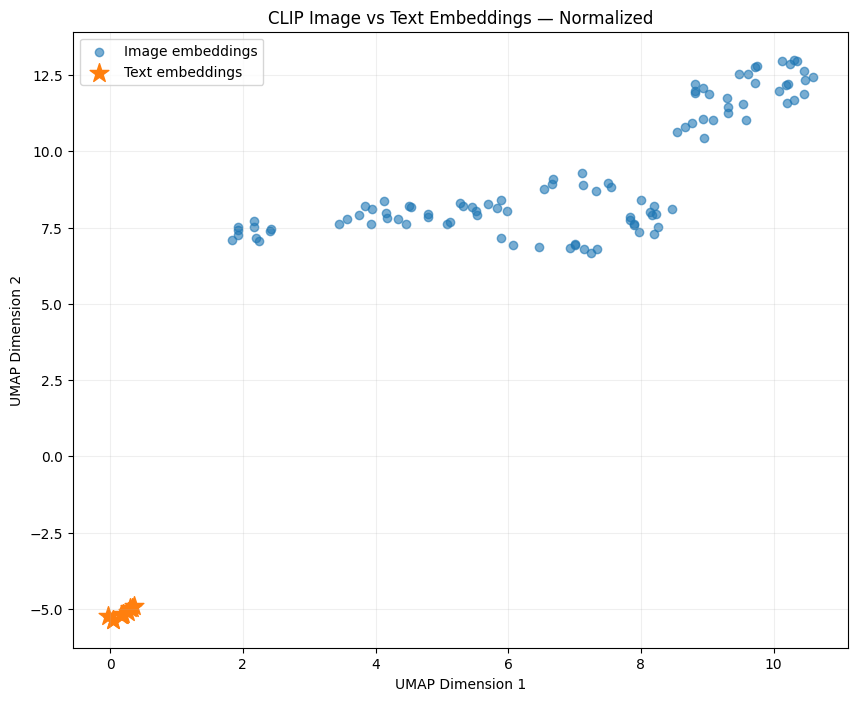

In [ ]:
plt.figure(figsize=(10, 8))

image_mask = np.array(modality) == "Image"
text_mask = np.array(modality) == "Text"

plt.scatter(
    embedding_2d[image_mask, 0],
    embedding_2d[image_mask, 1],
    alpha=0.6,
    label="Image embeddings"
)

plt.scatter(
    embedding_2d[text_mask, 0],
    embedding_2d[text_mask, 1],
    marker="*",
    s=200,
    label="Text embeddings"
)

plt.title("CLIP Image vs Text Embeddings — Normalized")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
!pip install adjustText

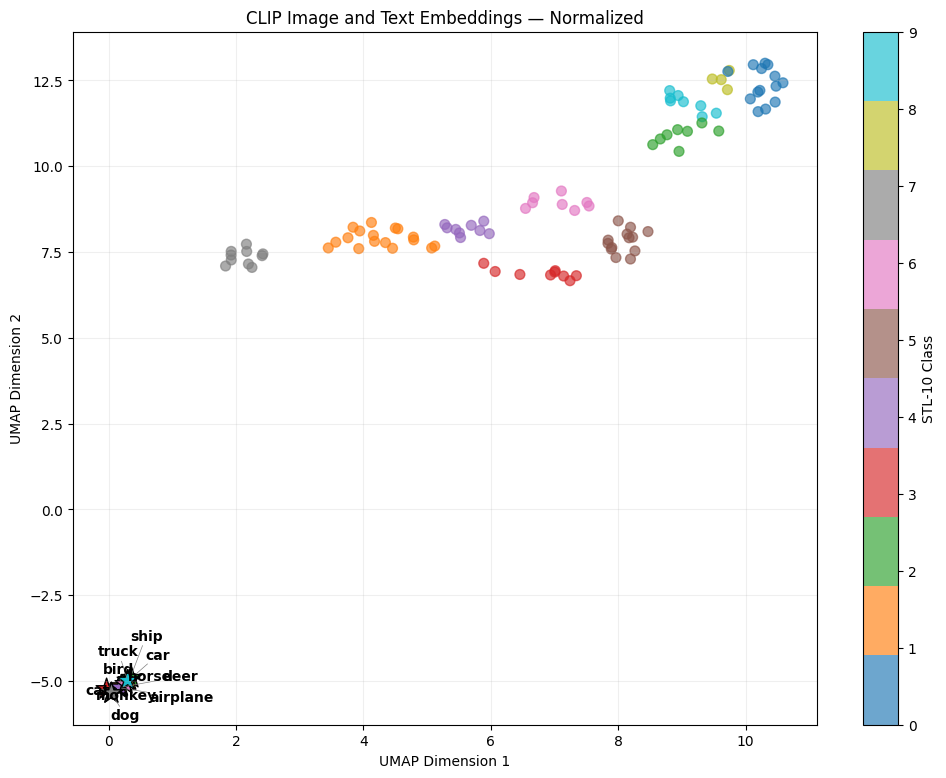

In [ ]:
# pip install adjustText --break-system-packages
from adjustText import adjust_text

plt.figure(figsize=(12, 9))

scatter = plt.scatter(
    embedding_2d[image_mask, 0],
    embedding_2d[image_mask, 1],
    c=np.array(combined_labels)[image_mask],
    cmap="tab10",
    alpha=0.65,
    s=50
)

plt.scatter(
    embedding_2d[text_mask, 0],
    embedding_2d[text_mask, 1],
    marker="*",
    s=250,
    c=np.array(combined_labels)[text_mask],
    cmap="tab10",
    edgecolors="black"
)

# Collect Text objects instead of placing them directly
texts = []
for i, class_name in enumerate(classes):
    idx = 100 + i
    texts.append(
        plt.text(
            embedding_2d[idx, 0],
            embedding_2d[idx, 1],
            class_name,
            fontsize=10,
            fontweight="bold"
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
)

plt.title("CLIP Image and Text Embeddings — Normalized")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label="STL-10 Class")
plt.grid(alpha=0.2)

plt.show()

In [ ]:
combined_unnormalized = torch.cat(
    [
        image_embeddings,
        text_embeddings
    ],
    dim=0
)

combined_unnormalized = combined_unnormalized.cpu().numpy()

In [ ]:
reducer_raw = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding_2d_raw = reducer_raw.fit_transform(
    combined_unnormalized
)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


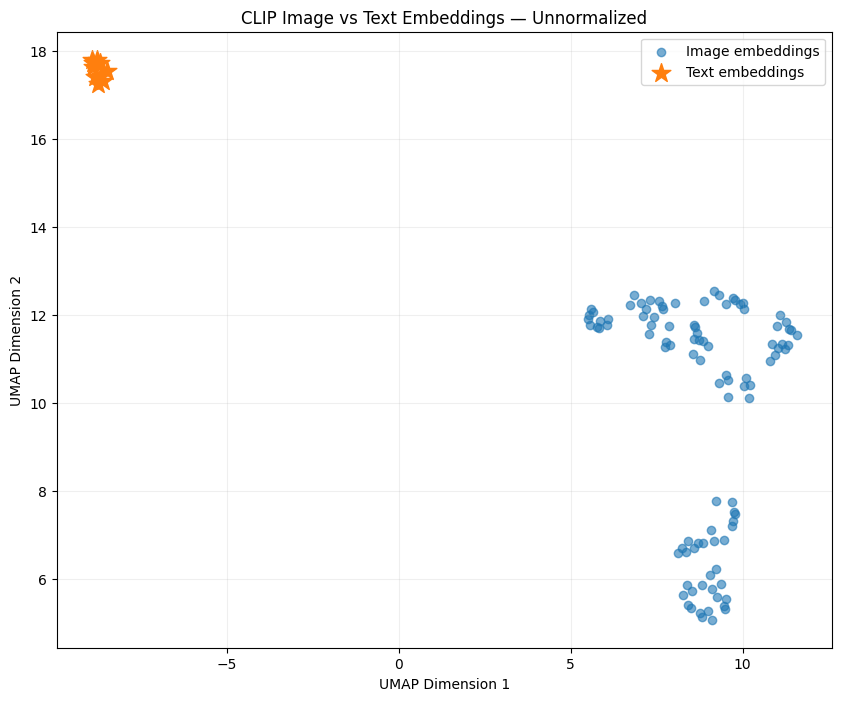

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    embedding_2d_raw[image_mask, 0],
    embedding_2d_raw[image_mask, 1],
    alpha=0.6,
    label="Image embeddings"
)

plt.scatter(
    embedding_2d_raw[text_mask, 0],
    embedding_2d_raw[text_mask, 1],
    marker="*",
    s=200,
    label="Text embeddings"
)

plt.title("CLIP Image vs Text Embeddings — Unnormalized")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

The UMAP visualization showed that image embeddings formed distinct clusters corresponding to visual classes, whereas the text embeddings were concentrated in a relatively compact region. This indicates a modality gap between the image and text embedding distributions. However, the apparent separation in the 2D projection does not prevent CLIP from performing well because CLIP relies on relative cross-modal similarity rather than requiring the two modalities to have identical distributions. Normalization further makes the representation magnitude-independent and causes similarity to correspond to cosine similarity, which is the basis of CLIP's zero-shot prediction.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import orthogonal_procrustes
import umap

In [ ]:
N_SAMPLES = 100

images = []
labels = []

for i in range(N_SAMPLES):
    image, label = dataset[i]
    images.append(image)
    labels.append(label)

images = torch.stack(images).to(DEVICE)
labels = torch.tensor(labels)

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([100, 3, 224, 224])
Labels: torch.Size([100])


In [ ]:
prompts = [
    "a photo of an airplane",
    "a photo of a bird",
    "a photo of a car",
    "a photo of a cat",
    "a photo of a deer",
    "a photo of a dog",
    "a photo of a horse",
    "a photo of a monkey",
    "a photo of a ship",
    "a photo of a truck"
]

text_tokens = clip.tokenize(prompts).to(DEVICE)

with torch.no_grad():
    text_embeddings = model.encode_text(text_tokens)

print(text_embeddings.shape)

torch.Size([10, 512])


In [ ]:
with torch.no_grad():
    image_embeddings = model.encode_image(images)

print(image_embeddings.shape)

torch.Size([100, 512])


In [ ]:
image_embeddings = (
    image_embeddings /
    image_embeddings.norm(dim=-1, keepdim=True)
)

text_embeddings = (
    text_embeddings /
    text_embeddings.norm(dim=-1, keepdim=True)
)

In [ ]:
paired_text_embeddings = text_embeddings[labels]

print("Image embeddings:", image_embeddings.shape)
print("Paired text embeddings:", paired_text_embeddings.shape)

Image embeddings: torch.Size([100, 512])
Paired text embeddings: torch.Size([100, 512])


In [ ]:
X = image_embeddings.cpu().numpy()
Y = paired_text_embeddings.cpu().numpy()

In [ ]:
R, scale = orthogonal_procrustes(X, Y)

print("R shape:", R.shape)
print("Scale:", scale)

R shape: (512, 512)
Scale: 87.293884


In [ ]:
R_tensor = torch.tensor(
    R,
    dtype=image_embeddings.dtype,
    device=DEVICE
)

identity = torch.eye(
    R.shape[0],
    device=DEVICE
)

orthogonality_error = torch.norm(
    R_tensor.T @ R_tensor - identity
)

print("Orthogonality error:", orthogonality_error.item())

Orthogonality error: 0.006625607144087553


In [ ]:
aligned_image_embeddings = image_embeddings @ R_tensor

In [ ]:
aligned_image_embeddings = (
    aligned_image_embeddings /
    aligned_image_embeddings.norm(
        dim=-1,
        keepdim=True
    )
)

In [ ]:
before_similarity = (
    image_embeddings * paired_text_embeddings
).sum(dim=1)

print(
    "Mean similarity BEFORE:",
    before_similarity.mean().item()
)

Mean similarity BEFORE: 0.267333984375


In [ ]:
after_similarity = (
    aligned_image_embeddings * paired_text_embeddings
).sum(dim=1)

print(
    "Mean similarity AFTER:",
    after_similarity.mean().item()
)

Mean similarity AFTER: 0.87255859375


In [ ]:
combined_before = torch.cat(
    [
        image_embeddings,
        text_embeddings
    ],
    dim=0
).cpu().numpy()

reducer_before = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_before = reducer_before.fit_transform(
    combined_before
)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


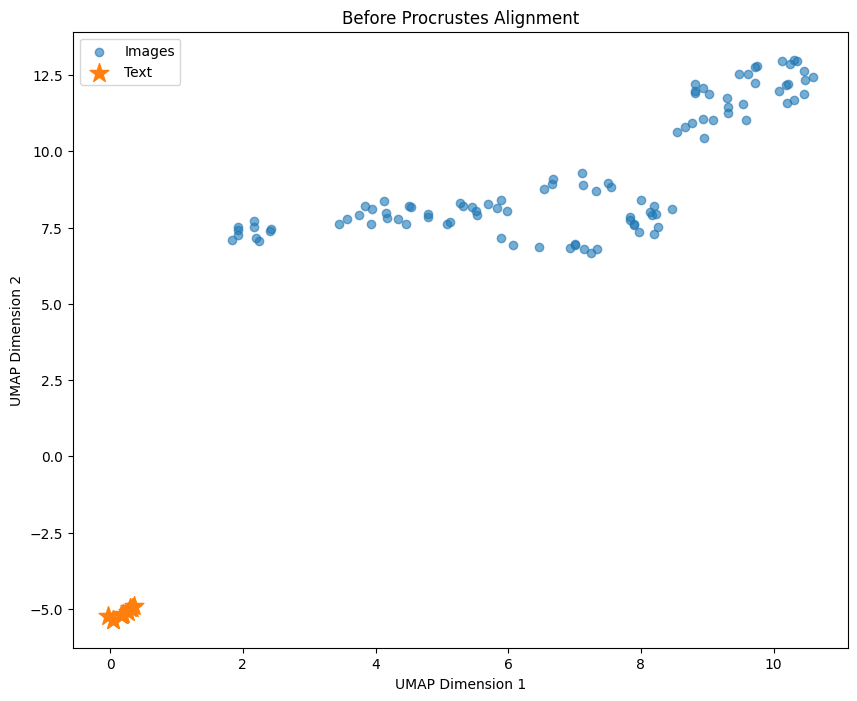

In [ ]:
image_mask = np.array(
    ["Image"] * 100 + ["Text"] * 10
) == "Image"

text_mask = ~image_mask

plt.figure(figsize=(10, 8))

plt.scatter(
    embedding_before[image_mask, 0],
    embedding_before[image_mask, 1],
    alpha=0.6,
    label="Images"
)

plt.scatter(
    embedding_before[text_mask, 0],
    embedding_before[text_mask, 1],
    marker="*",
    s=200,
    label="Text"
)

plt.title("Before Procrustes Alignment")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()

plt.show()

In [ ]:
combined_after = torch.cat(
    [
        aligned_image_embeddings,
        text_embeddings
    ],
    dim=0
).cpu().numpy()

In [ ]:
reducer_after = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_after = reducer_after.fit_transform(
    combined_after
)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_3128/1232513701.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  image_labels = np.array(labels[:100])


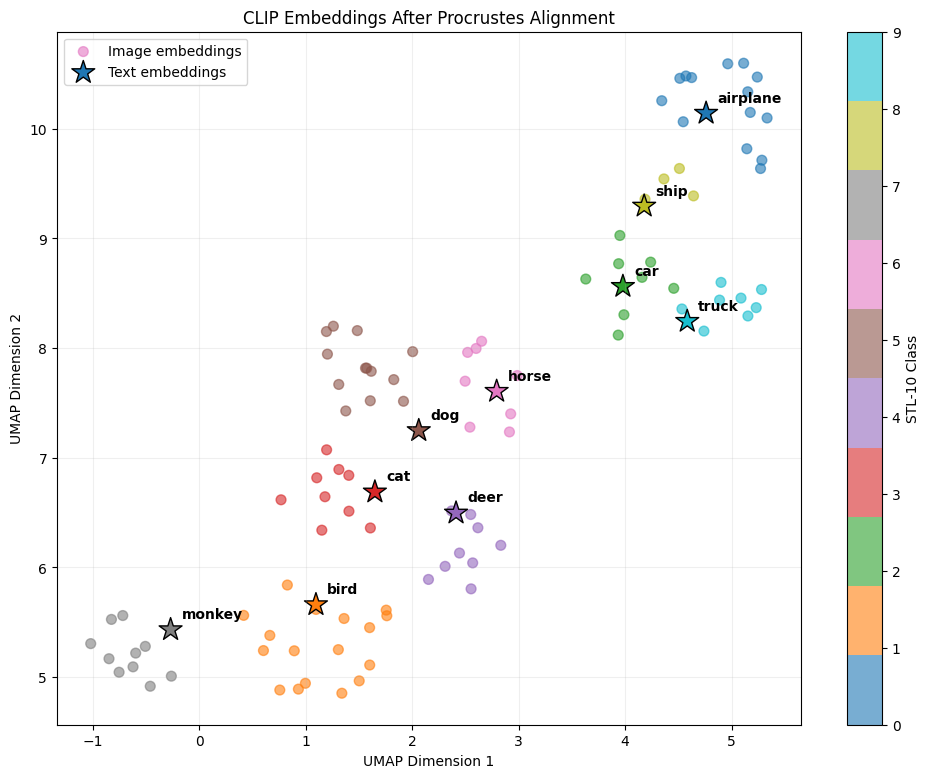

In [ ]:
plt.figure(figsize=(12, 9))

# Convert labels to numpy
image_labels = np.array(labels[:100])
text_labels = np.arange(10)

# ------------------------------------------------------------
# Plot image embeddings
# ------------------------------------------------------------

scatter = plt.scatter(
    embedding_after[:100, 0],
    embedding_after[:100, 1],
    c=image_labels,
    cmap="tab10",
    alpha=0.6,
    s=50,
    label="Image embeddings"
)

# ------------------------------------------------------------
# Plot text embeddings
# ------------------------------------------------------------

plt.scatter(
    embedding_after[100:, 0],
    embedding_after[100:, 1],
    c=text_labels,
    cmap="tab10",
    marker="*",
    s=300,
    edgecolors="black",
    linewidths=1.0,
    label="Text embeddings"
)

# ------------------------------------------------------------
# Label each text embedding
# ------------------------------------------------------------

for i, class_name in enumerate(classes):

    x = embedding_after[100 + i, 0]
    y = embedding_after[100 + i, 1]

    plt.annotate(
        class_name,
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.title("CLIP Embeddings After Procrustes Alignment")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.colorbar(
    scatter,
    ticks=range(10),
    label="STL-10 Class"
)

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
similarity_aligned = (
    aligned_image_embeddings @ text_embeddings.T
)

predictions_aligned = similarity_aligned.argmax(dim=1)

accuracy_aligned = (
    (predictions_aligned.cpu() == labels)
    .float()
    .mean()
    .item()
)

print(
    f"Aligned zero-shot accuracy: "
    f"{accuracy_aligned * 100:.2f}%"
)

Aligned zero-shot accuracy: 100.00%


In [ ]:
baseline_accuracy = 97.36
aligned_accuracy = accuracy_aligned * 100

print("=" * 50)
print("ZERO-SHOT ACCURACY COMPARISON (IN-SAMPLE)")
print("=" * 50)

print(f"Original CLIP:        {baseline_accuracy:.2f}%")
print(f"After Procrustes:     {aligned_accuracy:.2f}%")
print(
    f"Change:               "
    f"{aligned_accuracy - baseline_accuracy:+.2f} percentage points"
)

ZERO-SHOT ACCURACY COMPARISON (IN-SAMPLE)
Original CLIP:        97.36%
After Procrustes:     100.00%
Change:               +2.64 percentage points


In Sample Accuracy